In [2]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
import itertools
from scipy.stats import wilcoxon
def barplot_annotate_brackets(num1, num2, data, center, height, ax, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    if type(data) is str:
        text = data
    else:
        if data > 0.05:
          return
        # * is p < 0.05
        # ** is p < 0.005
        # *** is p < 0.0005
        # etc.
        text = ''
        p = .05

        while data < p:
            text += '*'
            p /= 10.

            if maxasterix and len(text) == maxasterix:
                break

        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    ax.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    ax.text(*mid, text, **kwargs)

In [4]:
metrics_dir=os.path.join(os.getcwd(),"metrics")
# --- LOAD THE .pkl FILE GENERATED PREVIOUSLY ---
adapt=[0,120,20,2]
test_ds_b4=False


combined_results=[]
for a in adapt:
    if test_ds_b4:
        identifier=f"testing_dsb4_adaptable{a}" if a > 0 else "testing_dsb4"
    else:
        identifier=f"30000_1000_100_adaptable{a}" if a > 0 else "30000_1000_100"
        # identifier="1000_200_median"
    filename = f"channel_metrics_by_network_{identifier}.csv"
    path = os.path.join(metrics_dir, filename)

    if os.path.exists(path):
        df = pd.read_csv(path)
        df["Adapt"] = a  # Add a column to identify the condition
        combined_results.append(df)
        print(f"Loaded: {filename}")
    else:
        print(f"Missing: {filename}")


# Combine all into one DataFrame
all_results_df = pd.concat(combined_results, ignore_index=True)

# Example usage:
print(all_results_df.groupby("Adapt")["F1"].mean())

Loaded: channel_metrics_by_network_30000_1000_100.csv
Loaded: channel_metrics_by_network_30000_1000_100_adaptable120.csv
Loaded: channel_metrics_by_network_30000_1000_100_adaptable20.csv
Loaded: channel_metrics_by_network_30000_1000_100_adaptable2.csv
Adapt
0      0.541775
2      0.582758
20     0.580822
120    0.570676
Name: F1, dtype: float64


In [9]:
import itertools
from scipy.stats import wilcoxon

def plot_f1_boxplot_by_adapt(df, metric):
    # Remove "Overall" if present
    df = df[df["Dataset"] != "Overall"].copy()
    colors = {
        "Precision": "royalblue",
        "Recall": "seagreen",
        "F1": "darkorange"
    }
    adapt_values = [0, 120, 20, 2]

    # Average metric per (Network, Adapt) over datasets
    mean_metric_per_net = df.groupby(["Network", "Adapt"])[metric].mean().reset_index()

    # Prepare data for boxplot
    data = [mean_metric_per_net[mean_metric_per_net["Adapt"] == a][metric].values for a in adapt_values]

    # Create a pivot table: rows = Network, columns = Adapt
    pivot = mean_metric_per_net.pivot(index="Network", columns="Adapt", values=metric)
    pivot = pivot[adapt_values]  # ensure adapt order

    adapt_data = pivot.values  # shape: (n_networks, n_adapt_values)
    network_names = pivot.index.tolist()

    fig, ax = plt.subplots(figsize=(8, 5))

    # Boxplot
    box = ax.boxplot(data, patch_artist=True, widths=0.6,
                     boxprops=dict(facecolor=colors[metric], color='black'),
                     medianprops=dict(color='black'),
                     whiskerprops=dict(color='black'),
                     capprops=dict(color='black'),
                     flierprops=dict(marker='o', color='gray', alpha=0.0))

    # Plot lines between adapt values for each network with jitter
    for row in adapt_data:
        jitter = np.random.normal(0, 0.05, size=len(row))
        ax.plot(range(1, len(adapt_values) + 1) + jitter, row, marker='o', linestyle='-', alpha=0.4, color='black')

    # Prepare for annotation
    centers = np.arange(1, len(adapt_values) + 1)
    max_heights = [np.max(vals) for vals in data]

    # Run Wilcoxon signed-rank tests between pairs and annotate if significant
    for a1, a2 in itertools.combinations(range(len(adapt_values)), 2):
        val1 = pivot[adapt_values[a1]]
        val2 = pivot[adapt_values[a2]]

        # Wilcoxon requires paired samples and no NaNs
        paired = val1.notna() & val2.notna()
        if paired.sum() > 0:
            stat, p = wilcoxon(val1[paired], val2[paired])
            barplot_annotate_brackets(a1, a2, p, centers, max_heights, ax)

    ax.set_xticks(centers)
    ax.set_xticklabels(adapt_values, fontsize=11)
    ax.set_xlabel("Adapt", fontsize=12)
    ax.set_ylabel(f"Mean {metric} (across 4 datasets)", fontsize=12)
    ax.set_title(f"{metric} Adaptive Threshold", fontsize=14)
    ax.set_ylim(0.4,0.85)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()
    return fig, ax


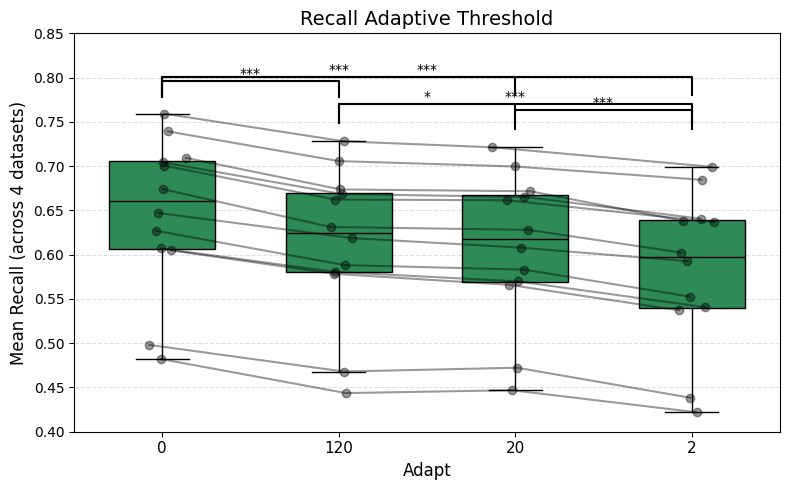

In [423]:
fig,ax=plot_f1_boxplot_by_adapt(all_results_df,metric="Recall")
fig.savefig("figures\\recall_boxplot_by_adapt.png", dpi=300, bbox_inches='tight')

In [10]:
def plot_f1_boxplot_by_adapt(df):
    # Remove "Overall" if present
    df = df[df["Dataset"] != "Overall"].copy()

    # Average F1 per (Network, Adapt) over the 4 datasets
    mean_f1_per_net = df.groupby(["Network", "Adapt"])["F1"].mean().reset_index()

    # Prepare data for boxplot
    adapt_values = [0,120,20,2]
    data = [mean_f1_per_net[mean_f1_per_net["Adapt"] == a]["F1"].values for a in adapt_values]
    fig, ax = plt.subplots(figsize=(8, 5))

    # Create a pivot table for easier access: rows = Network, columns = Adapt
    pivot = mean_f1_per_net.pivot(index="Network", columns="Adapt", values="F1")

    # Make sure columns are in correct adapt order
    pivot = pivot[adapt_values]

    # Store adapt-wise F1s per network for later use
    adapt_data = pivot.values  # shape: (n_networks, n_adapt_values)
    network_names = pivot.index.tolist()

    # Draw boxplot
    box = ax.boxplot(data, patch_artist=True, widths=0.6,
                     boxprops=dict(facecolor='orange', color='black'),
                     medianprops=dict(color='black'),
                     whiskerprops=dict(color='black'),
                     capprops=dict(color='black'),
                     flierprops=dict(marker='o', color='gray', alpha=0.0))

    # Plot lines between adapt values for each network
    for row in adapt_data:
        jitter= np.random.normal(0, 0.05, size=len(row))  # Add some jitter for visibility
        ax.plot(range(1, len(adapt_values)+1)+jitter, row,marker='o',linestyle='-', alpha=0.5, color='black')

    ax.set_xticks(range(1, len(adapt_values) + 1))
    ax.set_xticklabels(adapt_values, fontsize=11)
    ax.set_xlabel("Adapt", fontsize=12)
    ax.set_ylabel("Mean F1 (across 4 datasets)", fontsize=12)
    ax.set_title("F1 Score Adaptive Threshold", fontsize=14)
    # ax.set_ylim(0, 1)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()
    return fig, ax

In [11]:
from scipy.stats import ttest_ind
from itertools import combinations
import statsmodels.stats.multitest as smm

def test_adapt_groups(df, metric,alpha=0.05):
    """
    Perform pairwise Welch's t-tests on F1 scores across adapt levels,
    with Bonferroni correction for multiple comparisons.

    Parameters:
        df: DataFrame with at least ['Adapt', 'F1'] columns.
        alpha: Significance level for corrected p-values.
    """
    adapt_levels = sorted(df['Adapt'].unique())
    groups = {a: df[df['Adapt'] == a][metric].dropna() for a in adapt_levels}
    results = []

    # All pairwise combinations
    for a1, a2 in combinations(adapt_levels, 2):
        g1, g2 = groups[a1], groups[a2]
        stat, p = ttest_ind(g1, g2, equal_var=False)
        results.append((a1, a2, p))

    # Multiple testing correction
    p_raw = [r[2] for r in results]
    reject, p_corrected, _, _ = smm.multipletests(p_raw, alpha=alpha, method='bonferroni')

    # Output results
    print(f"Pairwise Adapt Comparisons ({metric}):")
    for i, (a1, a2, raw_p) in enumerate(results):
        sig = "✅" if reject[i] else "❌"
        print(f"{sig} Adapt {a1} vs {a2}: raw p = {raw_p:.4g}, corrected p = {p_corrected[i]:.4g}")


In [426]:
test_adapt_groups(df=all_results_df, metric="F1",alpha=0.05)
test_adapt_groups(df=all_results_df, metric="Precision",alpha=0.05)
test_adapt_groups(df=all_results_df, metric="Recall",alpha=0.05)


Pairwise Adapt Comparisons (F1):
✅ Adapt 0 vs 2: raw p = 3.506e-05, corrected p = 0.0002103
✅ Adapt 0 vs 20: raw p = 3.341e-05, corrected p = 0.0002004
✅ Adapt 0 vs 120: raw p = 0.001488, corrected p = 0.008927
❌ Adapt 2 vs 20: raw p = 0.8475, corrected p = 1
❌ Adapt 2 vs 120: raw p = 0.2178, corrected p = 1
❌ Adapt 20 vs 120: raw p = 0.2758, corrected p = 1
Pairwise Adapt Comparisons (Precision):
✅ Adapt 0 vs 2: raw p = 1.494e-17, corrected p = 8.966e-17
✅ Adapt 0 vs 20: raw p = 5.8e-10, corrected p = 3.48e-09
✅ Adapt 0 vs 120: raw p = 1.122e-05, corrected p = 6.733e-05
✅ Adapt 2 vs 20: raw p = 0.006893, corrected p = 0.04136
✅ Adapt 2 vs 120: raw p = 3.461e-06, corrected p = 2.077e-05
❌ Adapt 20 vs 120: raw p = 0.04702, corrected p = 0.2821
Pairwise Adapt Comparisons (Recall):
✅ Adapt 0 vs 2: raw p = 1.95e-05, corrected p = 0.000117
❌ Adapt 0 vs 20: raw p = 0.009344, corrected p = 0.05606
❌ Adapt 0 vs 120: raw p = 0.01936, corrected p = 0.1161
❌ Adapt 2 vs 20: raw p = 0.08342, correc

In [14]:
dataset_colors={
   "Amigo": "#8E44AD",
   "Dlx": "#E74C3C",
   "Som": "#FFC300",
   "Thy": "#17BECF"
}

def plot_f1_boxplot_by_dataset_and_adapt(df, avg_within_dataset=True,back_colors=None):
    """
    Plots F1 score boxplots grouped by dataset and adapt condition.

    Parameters
    ----------
    df : pd.DataFrame
        Must have columns ["Network", "Dataset", "Adapt", "F1"].
    avg_within_dataset : bool
        If True, average channels within each dataset before plotting.
        If False, plot per-channel values directly.
    """
    df = df.copy()
    adapt_values = [0, 120, 20, 2]
    datasets = sorted(df["Dataset"].unique())

    fig, ax = plt.subplots(figsize=(12, 7))

    width = 0.5
    n_adapt = len(adapt_values)
    n_datasets = len(datasets)   # includes "Overall"
    colors = plt.cm.viridis_r(np.linspace(0.2, 0.8, n_adapt))

    positions = []
    data = []
    labels=["Amigo","Dlx","Som","Thy"]

    # --- Per-dataset plotting ---
    for i, dataset in enumerate(datasets):
        subset = df[df["Dataset"] == dataset]

        if avg_within_dataset:
            # Average channels within each Network/Dataset/Adapt
            subset = subset.groupby(["Network", "Adapt"])["F1"].mean().reset_index()
            pivot_index = "Network"
        else:
            # Keep per-channel entries
            subset = subset.groupby(["Network", "Dataset", "Channel", "Adapt"])["F1"].mean().reset_index()
            pivot_index = ["Network", "Channel"]  # ensures uniqueness

        pivot = subset.pivot(index=pivot_index, columns="Adapt", values="F1").reindex(columns=adapt_values)


        for j, adapt in enumerate(adapt_values):
            vals = pivot[adapt].dropna().values
            pos = i * (n_adapt + 1) + j
            data.append(vals)
            positions.append(pos)

    # if avg_within_dataset:
    #     overall_means = df.groupby(["Network", "Adapt"])["F1"].mean().reset_index()
    #     pivot_index = "Network"
    # else:
    #     overall_means = df.groupby(["Network", "Dataset", "Channel", "Adapt"])["F1"].mean().reset_index()
    #     pivot_index = ["Network", "Channel"]

    # overall_pivot = overall_means.pivot(index=pivot_index, columns="Adapt", values="F1").reindex(columns=adapt_values)


    # overall_pos_start = len(datasets) * (n_adapt + 1)
    # for j, adapt in enumerate(adapt_values):
    #     vals = overall_pivot[adapt].dropna().values
    #     pos = overall_pos_start + j
    #     data.append(vals)
    #     positions.append(pos)

    # --- Boxplots ---
    for idx, (vals, pos) in enumerate(zip(data, positions)):
        color = colors[idx % n_adapt]
        bplot = ax.boxplot(vals, positions=[pos], widths=width, patch_artist=True,
                           showfliers=False, medianprops=dict(color='black'))
        
        for patch in bplot['boxes']:
            patch.set_facecolor(color)
    # --- Background shading per dataset ---
    if back_colors:
        for i, label in enumerate(labels):
            if label in back_colors:
                start = i * (n_adapt + 1) - 0.5
                end = start + n_adapt
                ax.axvspan(start, end, color=back_colors[label], alpha=0.15, zorder=0)
    # --- X-axis labels ---
    xticks = []
    # labels = datasets # + ["Overall"]
    for i in range(n_datasets):
        center = i * (n_adapt + 1) + (n_adapt - 1) / 2
        xticks.append(center)
    ax.set_xticks(xticks)
    ax.set_xticklabels(labels, fontsize=12)

    # --- Labels and formatting ---
    ax.set_xlabel("Dataset", fontsize=14)
    ax.set_ylabel("Mean F1" if avg_within_dataset else "F1 (per channel)", fontsize=14)
    ax.set_title("F1 Score per Dataset and Adapt Condition", fontsize=16)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.tick_params(axis="both", which='major', labelsize=14)
    ax.set_ylim(0.40,0.85)
    # --- Legend ---
    adapt_labels = [f"Adapt {a}" for a in adapt_values]
    legend_patches = [
        plt.Line2D([0], [0], color=colors[i], marker='s', markersize=10, label=adapt_labels[i])
        for i in range(n_adapt)
    ]
    # ax.legend(handles=legend_patches, fontsize=12, loc='upper left')

    plt.tight_layout()
    plt.show()
    return fig, ax


In [5]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu,wilcoxon

def holm_bonferroni(p_values, alpha=0.05):
    """Apply Holm–Bonferroni correction to a list of p-values."""
    m = len(p_values)
    sorted_indices = np.argsort(p_values)
    sorted_pvals = np.array(p_values)[sorted_indices]
    reject = np.zeros(m, dtype=bool)
    adjusted_pvals = np.zeros(m)

    for k, p in enumerate(sorted_pvals):
        threshold = alpha / (m - k)
        if p <= threshold:
            reject[sorted_indices[k]] = True
        adjusted_pvals[sorted_indices[k]] = min(p * (m - k), 1.0)

    return adjusted_pvals, reject

def plot_f1_boxplot_by_dataset_and_adapt(df, avg_within_dataset=True, back_colors=None):
    """
    Plots F1 score boxplots grouped by dataset and adapt condition,
    with Mann–Whitney U significance annotations between adapt conditions.

    Parameters
    ----------
    df : pd.DataFrame
        Must have columns ["Network", "Dataset", "Adapt", "F1"].
    avg_within_dataset : bool
        If True, average channels within each dataset before plotting.
        If False, plot per-channel values directly.
    back_colors : dict or None
        Optional shading colors per dataset.
    """
    df = df.copy()
    adapt_values = [0, 120, 20, 2]
    datasets = sorted(df["Dataset"].unique())

    fig, ax = plt.subplots(figsize=(12, 7))

    width = 0.8
    n_adapt = len(adapt_values)
    n_datasets = len(datasets)
    colors = plt.cm.viridis_r(np.linspace(0.2, 0.8, n_adapt))

    positions, data, max_heights = [], [], []
    labels = ["Amigo","Dlx", "Som", "Thy"]
    # --- Per-dataset plotting ---
    for i, dataset in enumerate(datasets):
        subset = df[df["Dataset"] == dataset]

        if avg_within_dataset:
            subset = subset.groupby(["Network", "Adapt"])["F1"].mean().reset_index()
            pivot_index = "Network"
        else:
            subset = subset.groupby(["Network", "Dataset", "Channel", "Adapt"])["F1"].mean().reset_index()
            pivot_index = ["Network", "Channel"]

        pivot = subset.pivot(index=pivot_index, columns="Adapt", values="F1").reindex(columns=adapt_values)

        for j, adapt in enumerate(adapt_values):
            vals = pivot[adapt].dropna().values
            pos = i * (n_adapt + 1) + j
            data.append(vals)
            positions.append(pos)

    # --- Boxplots ---
    for idx, (vals, pos) in enumerate(zip(data, positions)):
        color = colors[idx % n_adapt]
        bplot = ax.boxplot(vals, positions=[pos], widths=width, patch_artist=True,
                           showfliers=False, medianprops=dict(color='black'))
        for patch in bplot['boxes']:
            patch.set_facecolor(color)

        max_heights.append(np.max(vals) if len(vals) > 0 else 0)

    # --- Background shading per dataset ---
    if back_colors:
        for i, label in enumerate(labels):
            if label in back_colors:
                start = i * (n_adapt + 1) - 0.5
                end = start + n_adapt
                ax.axvspan(start, end, color=back_colors[label], alpha=0.15, zorder=0)

    # --- Significance tests within each dataset ---
    for i, dataset in enumerate(datasets):
        start_idx = i * n_adapt
        dataset_vals = data[start_idx:start_idx + n_adapt]
        dataset_pos = positions[start_idx:start_idx + n_adapt]
        dataset_heights = max_heights[start_idx:start_idx + n_adapt]

        pairs = list(itertools.combinations(range(n_adapt), 2))
        raw_pvals = []

            # --- compute all p-values first ---
        for (j1, j2) in pairs:
            vals1, vals2 = dataset_vals[j1], dataset_vals[j2]
            if len(vals1) > 0 and len(vals2) > 0:
                try:
                    _, pval = wilcoxon(vals1, vals2, alternative="two-sided")
                except ValueError:
                    pval = 1.0
            else:
                pval = 1.0
            raw_pvals.append(float(pval))   # <-- force to float

        # adjust with Holm-Bonferroni
        # adj_pvals = [float(p) for p in holm_bonferroni(raw_pvals)]
        adj_pvals, _ = holm_bonferroni(raw_pvals)
        # keep track of annotation levels so brackets stack
        annotation_levels = np.zeros(n_adapt)

        # annotate with corrected p-values
        for (pval, (j1, j2)) in zip(adj_pvals, pairs):
            level = int(max(annotation_levels[j1], annotation_levels[j2]))
            # shift height upward based on level
            heights_for_bracket = [h + 0.03 * level for h in dataset_heights]

            print(f"Dataset: {dataset}, Adapt {adapt_values[j1]} vs {adapt_values[j2]}, "
                f"raw p = {raw_pvals[pairs.index((j1,j2))]:.4e}, adj p = {pval:.4e}")

            barplot_annotate_brackets(j1, j2, pval,
                                    dataset_pos,
                                    heights_for_bracket,
                                    ax,
                                    dh=0.01, barh=0.00, fs=12)

            # if significant, bump the bracket level so next comparison stacks higher
            if pval < 0.05:
                annotation_levels[j1] = annotation_levels[j2] = level + 1

    # --- X-axis labels ---
    xticks = []
    for i in range(n_datasets):
        center = i * (n_adapt + 1) + (n_adapt - 1) / 2
        xticks.append(center)
    ax.set_xticks(xticks)
    ax.set_xticklabels(labels, fontsize=12)

    # --- Labels and formatting ---
    ax.set_xlabel("Dataset", fontsize=14)
    ax.set_ylabel("Mean F1" if avg_within_dataset else "F1 (per channel)", fontsize=14)
    ax.set_title("F1 Score per Dataset and Adapt Condition", fontsize=16)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.tick_params(axis="both", which='major', labelsize=14)
    ax.set_ylim(0.40, 0.95)

    # --- Legend ---
    adapt_labels = [f"Adapt {a}" for a in adapt_values]
    legend_patches = [
        plt.Line2D([0], [0], color=colors[i], marker='s', markersize=10, label=adapt_labels[i])
        for i in range(n_adapt)
    ]
    ax.legend(handles=legend_patches, fontsize=12, loc='upper left')

    plt.tight_layout()
    plt.show()
    return fig, ax


Dataset: Amigo2_2019-07-11_11-57-07, Adapt 0 vs 120, raw p = 4.8828e-04, adj p = 2.9297e-03
Dataset: Amigo2_2019-07-11_11-57-07, Adapt 0 vs 20, raw p = 1.4648e-03, adj p = 4.3945e-03
Dataset: Amigo2_2019-07-11_11-57-07, Adapt 0 vs 2, raw p = 8.5010e-01, adj p = 8.5010e-01
Dataset: Amigo2_2019-07-11_11-57-07, Adapt 120 vs 20, raw p = 9.2285e-02, adj p = 1.8457e-01
Dataset: Amigo2_2019-07-11_11-57-07, Adapt 120 vs 2, raw p = 4.8828e-04, adj p = 2.4414e-03
Dataset: Amigo2_2019-07-11_11-57-07, Adapt 20 vs 2, raw p = 4.8828e-04, adj p = 1.9531e-03
Dataset: Dlx1_2021-02-12_12-46-54, Adapt 0 vs 120, raw p = 4.8828e-04, adj p = 2.9297e-03
Dataset: Dlx1_2021-02-12_12-46-54, Adapt 0 vs 20, raw p = 4.8828e-04, adj p = 2.4414e-03
Dataset: Dlx1_2021-02-12_12-46-54, Adapt 0 vs 2, raw p = 4.8828e-04, adj p = 1.9531e-03
Dataset: Dlx1_2021-02-12_12-46-54, Adapt 120 vs 20, raw p = 2.4414e-03, adj p = 7.3242e-03
Dataset: Dlx1_2021-02-12_12-46-54, Adapt 120 vs 2, raw p = 2.4414e-03, adj p = 4.8828e-03
Dat

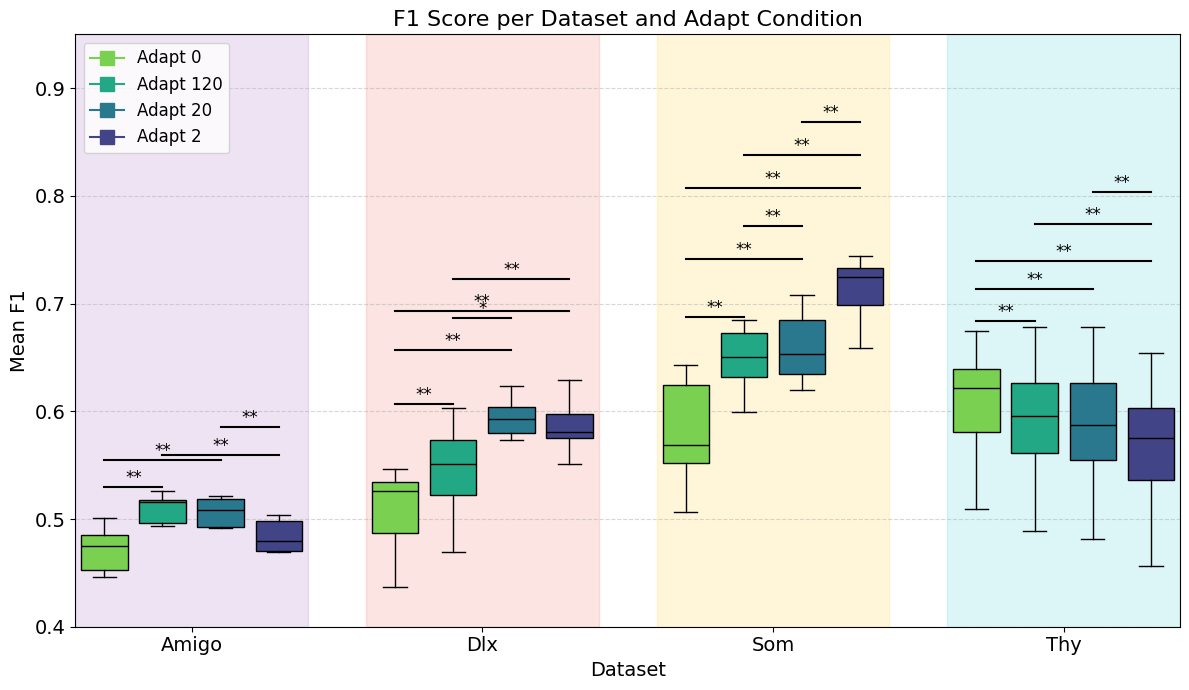

In [69]:
fig,ax=plot_f1_boxplot_by_dataset_and_adapt(all_results_df,avg_within_dataset=True,back_colors=dataset_colors)
# fig.savefig("figures\\f1_boxplot_by_dataset_and_adapt.png", dpi=300, bbox_inches='tight')

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_prf1_boxplot_by_adapt(df, group_level="Network"):
    """
    group_level: "Channel", "Dataset", or "Network"
    """
    df = df[df["Dataset"] != "Overall"].copy()
    metrics = ["Precision", "Recall", "F1"]
    adapt_values = [0, 120, 20, 2]
    labels = ["Fixed", "60", "10", "1"]
    colors = {
        "Precision": "royalblue",
        "Recall": "seagreen",
        "F1": "darkorange"
    }

    # Assign unique markers & colors for networks
    networks = df["Network"].unique()
    marker_styles = ["o", "s", "D", "^", "v", "*", "P", "X"]
    net_markers = {net: marker_styles[i % len(marker_styles)] for i, net in enumerate(networks)}
    net_colors = plt.cm.tab10(np.linspace(0, 1, len(networks)))
    net_colors=plt.color_gradients
    # Decide group columns
    if group_level == "Channel":
        group_cols = ["Network", "Dataset", "Channel", "Adapt"]
    elif group_level == "Dataset":
        group_cols = ["Network", "Dataset", "Adapt"]
    elif group_level == "Network":
        group_cols = ["Network", "Adapt"]
    else:
        raise ValueError("group_level must be 'Channel', 'Dataset', or 'Network'.")

    # Average metric values per group
    mean_metrics = df.groupby(group_cols)[metrics].mean().reset_index()

    fig, ax = plt.subplots(figsize=(10, 6))
    width = 0.25
    spacing = 0.2

    positions = []
    data = []
    plot_colors = []

    # Base x positions for each adapt group
    x_base = np.arange(len(adapt_values)) * (len(metrics) * width + spacing)

    # Grey background bands
    for j in range(len(adapt_values)):
        group_start = x_base[j] - width/1.5
        group_end = x_base[j] + len(metrics) * width - width / 3
        ax.axvspan(group_start, group_end, color="lightgray", alpha=0.1, zorder=0)

    # Collect data and positions
    for i, metric in enumerate(metrics):
        for j, adapt in enumerate(adapt_values):
            vals = mean_metrics[mean_metrics["Adapt"] == adapt][metric].dropna().values
            pos = x_base[j] + i * width
            data.append(vals)
            positions.append(pos)
            plot_colors.append(colors[metric])

    # Draw boxplots
    for vals, pos, color in zip(data, positions, plot_colors):
        bplot = ax.boxplot(vals, positions=[pos], widths=width, patch_artist=True,
                           showfliers=False, medianprops=dict(color='black'))
        for patch in bplot['boxes']:
            patch.set_facecolor(color)
    
    # Plot points + lines for each network
    for j, adapt in enumerate(adapt_values):
        subset = mean_metrics[mean_metrics["Adapt"] == adapt]
        for k, entity in enumerate(subset[group_cols[0]].unique()):  # first column is "Network"
            net_data = subset[subset[group_cols[0]] == entity]
            y_vals = [net_data[m].values[0] if not net_data.empty else np.nan for m in metrics]
            jitter = np.random.normal(0, 0.03, size=len(metrics))  # Add jitter for visibility
            x_vals = [x_base[j] + i * width + jitter[i] for i in range(len(metrics))]
            for xi, yi, m in zip(x_vals, y_vals, metrics):
                # ax.scatter(xi, yi, color="black", s=50, edgecolor='black', zorder=2, alpha=0.5)
                ax.scatter(
                x_vals, y_vals,
                marker=net_markers[entity],
                color=net_colors[k],
                edgecolor='black',
                s=60,
                alpha=0.8,
                zorder=3,
                label=entity if j == 0 else None  # label only once in legend
            )

            # ax.plot(x_vals, y_vals, marker='o', markersize=6, color='black', alpha=0.2, zorder=3)


    # X-axis
    ax.set_xticks(x_base + width)
    ax.set_xticklabels(labels, fontsize=14)
    ax.set_xlabel("Adapt", fontsize=14)

    # Y-axis
    ax.set_ylabel(f"Score ({group_level}-averaged)", fontsize=14)
    ax.set_title(f"Precision, Recall, and F1 vs Adapt ({group_level})", fontsize=16)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_ylim(0.4, 0.8)
    ax.tick_params(axis='both', which='major', labelsize=14)

    # Legend
    legend_handles = [plt.Line2D([0], [0], color=colors[m], lw=4, label=m) for m in metrics]
    # ax.legend(handles=legend_handles, loc='upper left', fontsize=11)

    plt.tight_layout()
    plt.show()
    return fig, ax


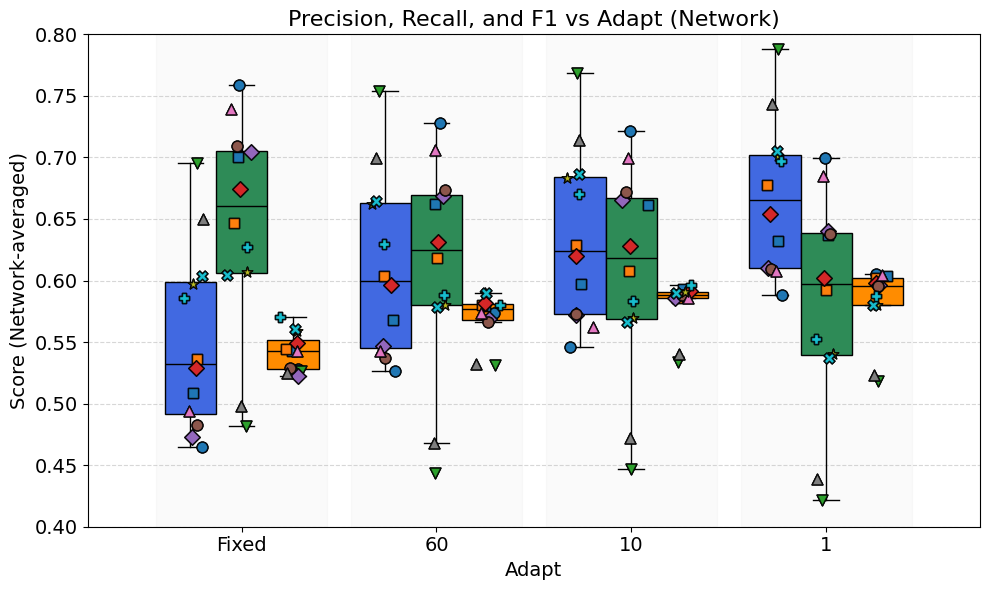

In [6]:
group_level = "Network"
fig,ax=plot_prf1_boxplot_by_adapt(all_results_df,group_level=group_level)
# fig.savefig(f"figures\\prf1_points_by_adapt_{group_level}.png", dpi=300, bbox_inches='tight')

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import itertools
from scipy.stats import wilcoxon

def holm_bonferroni_correction(pvals):
    """Holm-Bonferroni step-down correction."""
    m = len(pvals)
    sorted_idx = np.argsort(pvals)
    adjusted = np.empty(m)
    for k, i in enumerate(sorted_idx):
        adjusted[i] = min((m - k) * pvals[i], 1.0)
    return adjusted

def plot_prf1_boxplot_by_metric(df, group_level="Network"):
    df = df[df["Dataset"] != "Overall"].copy()
    metrics = ["Precision", "Recall", "F1"]
    adapt_values = [0, 120, 20, 2]
    labels = ["Fixed", "60", "10", "1"]
    n_adapt = len(adapt_values)

    # Background colors by metric
    metric_backcolors = {
        "Precision": "royalblue",
        "Recall": "seagreen",
        "F1": "darkorange"
    }
    # Adapt colors
    adapt_colors = plt.cm.viridis_r(np.linspace(0.2, 0.8, n_adapt))

    # Decide group columns
    if group_level == "Channel":
        group_cols = ["Network", "Dataset", "Channel", "Adapt"]
    elif group_level == "Dataset":
        group_cols = ["Network", "Dataset", "Adapt"]
    elif group_level == "Network":
        group_cols = ["Network", "Adapt"]
    else:
        raise ValueError("group_level must be 'Channel', 'Dataset', or 'Network'.")

    mean_metrics = df.groupby(group_cols)[metrics].mean().reset_index()

    fig, ax = plt.subplots(figsize=(10, 6))
    width = 0.25
    spacing = 0.4

    positions, data, plot_colors = [], [], []
    x_base = np.arange(len(metrics)) * (n_adapt * width + spacing)

    # --- Background shading per metric ---
    for j, metric in enumerate(metrics):
        group_start = x_base[j] - width/2
        group_end = x_base[j] + n_adapt * width - width/2
        ax.axvspan(group_start-0.1, group_end+0.1, 
                   color=metric_backcolors[metric], 
                   alpha=0.2, zorder=0)

    # --- Collect data and positions ---
    for j, metric in enumerate(metrics):
        for k, adapt in enumerate(adapt_values):
            vals = mean_metrics[mean_metrics["Adapt"] == adapt][metric].dropna().values
            pos = x_base[j] + k * width
            data.append(vals)
            positions.append(pos)
            plot_colors.append(adapt_colors[k])

    # --- Draw boxplots ---
    max_heights = []
    for vals, pos, color in zip(data, positions, plot_colors):
        bplot = ax.boxplot(vals, positions=[pos], widths=width, patch_artist=True,
                           showfliers=False, medianprops=dict(color='black'))
        for patch in bplot['boxes']:
            patch.set_facecolor(color)
        if len(vals) > 0:
            max_heights.append(np.max(vals))
        else:
            max_heights.append(0)

    # --- Statistical testing within each metric ---
    for i, metric in enumerate(metrics):
        start_idx = i * n_adapt
        metric_vals = data[start_idx:start_idx + n_adapt]
        metric_pos = positions[start_idx:start_idx + n_adapt]
        metric_heights = max_heights[start_idx:start_idx + n_adapt]

        pairs = list(itertools.combinations(range(n_adapt), 2))
        raw_pvals = []

        # collect raw p-values
        for (j1, j2) in pairs:
            vals1, vals2 = metric_vals[j1], metric_vals[j2]
            if len(vals1) > 0 and len(vals2) > 0:
                try:
                    _, pval = wilcoxon(vals1, vals2, alternative="two-sided")
                except ValueError:
                    pval = 1.0
            else:
                pval = 1.0
            raw_pvals.append(float(pval))

        adj_pvals = holm_bonferroni_correction(raw_pvals)

        annotation_levels = np.zeros(n_adapt)

        for (j, (j1, j2)) in enumerate(pairs):
            pval = adj_pvals[j]
            level = max(annotation_levels[j1], annotation_levels[j2])
            heights_for_bracket = [h + 0.04*level for h in metric_heights]

            print(f"Metric: {metric}, Adapt {labels[j1]} vs {labels[j2]}, "
                  f"raw p = {raw_pvals[j]:.4e}, adj p = {pval:.4e}")

            # barplot_annotate_brackets(j1, j2, pval,
            #                           metric_pos,
            #                           heights_for_bracket,
            #                           ax,
            #                           dh=0.02, barh=0.02, fs=12)

            if pval < 0.05:
                annotation_levels[j1] = annotation_levels[j2] = level + 1

    # --- X-axis ---
    ax.set_xticks(x_base + (n_adapt-1) * width / 2)
    ax.set_xticklabels(metrics, fontsize=14)
    ax.set_xlabel("Metric", fontsize=14)

    # --- Y-axis ---
    ax.set_ylabel(f"Score ({group_level}-averaged)", fontsize=14)
    ax.set_title(f"Precision, Recall, and F1 vs Adapt ({group_level})", fontsize=16)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_ylim(0.4, 0.85)
    ax.tick_params(axis='both', which='major', labelsize=14)

    # Legend for adapt values
    adapt_handles = [plt.Line2D([0],[0], color=adapt_colors[k], lw=4, label=labels[k]) for k in range(n_adapt)]
    # ax.legend(handles=adapt_handles, title="Adapt", fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()
    return fig, ax

Metric: Precision, Adapt Fixed vs 60, raw p = 4.8828e-04, adj p = 2.9297e-03
Metric: Precision, Adapt Fixed vs 10, raw p = 4.8828e-04, adj p = 2.4414e-03
Metric: Precision, Adapt Fixed vs 1, raw p = 4.8828e-04, adj p = 1.9531e-03
Metric: Precision, Adapt 60 vs 10, raw p = 4.8828e-04, adj p = 1.4648e-03
Metric: Precision, Adapt 60 vs 1, raw p = 4.8828e-04, adj p = 9.7656e-04
Metric: Precision, Adapt 10 vs 1, raw p = 4.8828e-04, adj p = 4.8828e-04
Metric: Recall, Adapt Fixed vs 60, raw p = 4.8828e-04, adj p = 2.9297e-03
Metric: Recall, Adapt Fixed vs 10, raw p = 4.8828e-04, adj p = 2.4414e-03
Metric: Recall, Adapt Fixed vs 1, raw p = 4.8828e-04, adj p = 1.9531e-03
Metric: Recall, Adapt 60 vs 10, raw p = 2.6855e-02, adj p = 2.6855e-02
Metric: Recall, Adapt 60 vs 1, raw p = 4.8828e-04, adj p = 1.4648e-03
Metric: Recall, Adapt 10 vs 1, raw p = 4.8828e-04, adj p = 9.7656e-04
Metric: F1, Adapt Fixed vs 60, raw p = 4.8828e-04, adj p = 2.9297e-03
Metric: F1, Adapt Fixed vs 10, raw p = 4.8828e-0

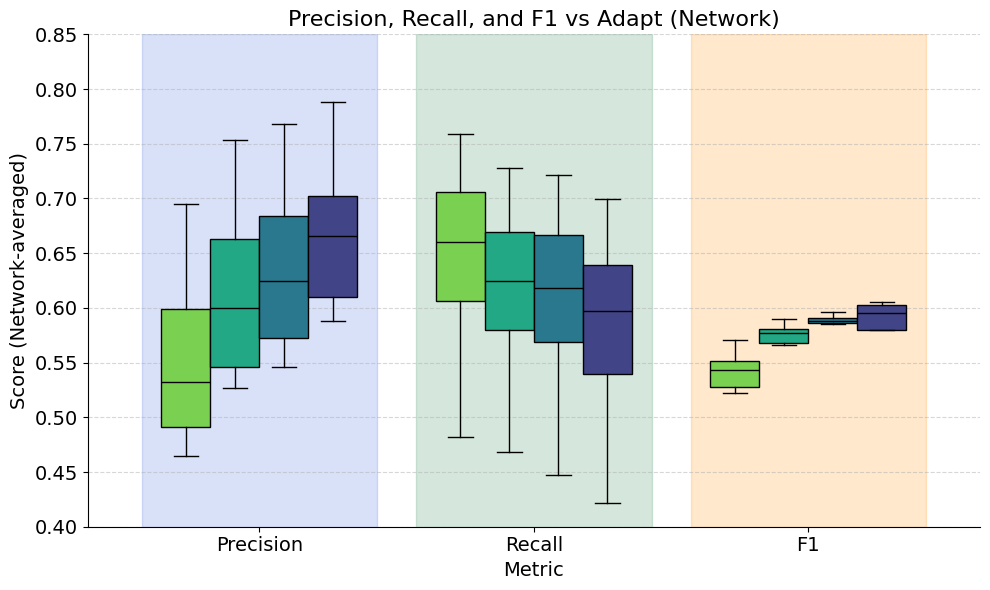

In [21]:
fig,ax=plot_prf1_boxplot_by_metric(all_results_df, group_level="Network")
fig.savefig("figures\\prf1_boxplot_by_metric_grouped.png", dpi=300, bbox_inches='tight')

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def plot_precision_recall_by_adapt(df):
    adapt_values = [0, 120, 20, 2]
    adapt_labels = [f"Adapt {a}" for a in adapt_values]
    # colors = {
    #     0: "#E69F00",    # orange
    #     2: "#009E73",    # green
    #     20: "#56B4E9",   # sky blue
    #     120: "#D55E00",  # reddish
    # }
    n_adapt = len(adapt_values)
    markers=["o","s","*","D"]
    markersize=2
    colors = plt.cm.viridis_r(np.linspace(0.2, 0.8, n_adapt))

    # Average Precision and Recall over datasets per (Network, Adapt)
    grouped = df.groupby(["Network", "Adapt"])[["Precision", "Recall"]].mean().reset_index()

    fig,ax = plt.subplots(figsize=(7, 6))

    for i, adapt in enumerate(adapt_values):
        subset = grouped[grouped["Adapt"] == adapt]
        ax.scatter(
            subset["Recall"], subset["Precision"],
            label=f"Adapt {adapt}",
            color=colors[i],
            alpha=0.8,
            s=80,
            edgecolors='black',
            marker=markers[i],
        )

     # F1 score contours
    f1_scores = [0.5, 0.6, 0.65, 0.7,]
    recall_vals = np.linspace(0.4, 0.9, 200)
    for f1 in f1_scores:
        precision_vals = (f1 * recall_vals) / (2 * recall_vals - f1)
        # Only keep valid values (P between 0 and 1)
        valid = (precision_vals >= 0) & (precision_vals <= 1)
        ax.plot(recall_vals[valid], precision_vals[valid],
                linestyle='--', color='gray', alpha=0.5)
        # Annotate near the top right
        idx = np.argmax(valid)
        # if idx > 0:
        #     ax.text(recall_vals[valid][-1], precision_vals[valid][-1],
        #             f"F1={f1:.1f}", fontsize=10, ha='left', va='center', color='gray')
    plt.xlim(0.4,0.8 )
    plt.ylim(0.4, 0.8)
    plt.xlabel("Recall", fontsize=14)
    plt.ylabel("Precision", fontsize=14)
    plt.title("Precision vs. Recall by Adapt", fontsize=16)
    # plt.legend(title="Adapt", title_fontsize=14, fontsize=14, loc='best')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tick_params(axis='both', which='major', labelsize=14)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()
    return fig, ax

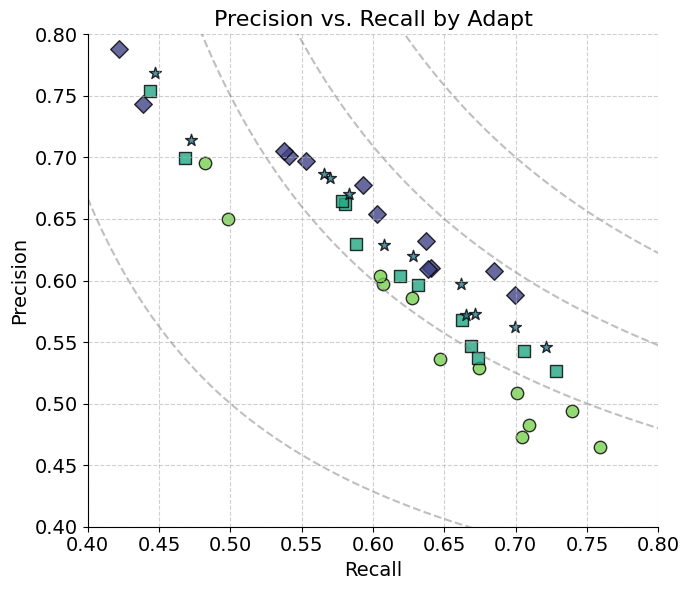

In [14]:
fig,ax=plot_precision_recall_by_adapt(all_results_df)
fig.savefig("figures\\precision_recall_by_adapt.png", dpi=300, bbox_inches='tight')

In [245]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def plot_f1_relative_change_by_adapt(df, metric, percent=False):
    # Remove "Overall" if present
    df = df[df["Dataset"] != "Overall"].copy()
    colors = {
        "Precision": "royalblue",
        "Recall": "seagreen",
        "F1": "darkorange"
    }
    adapt_values=[0,120,20,2]
    # Average metric per (Network, Adapt) over the datasets
    mean_metric_per_net = df.groupby(["Network", "Adapt"])[metric].mean().reset_index()

    # Create pivot table for ease of calculations: rows = Network, columns = Adapt
    pivot = mean_metric_per_net.pivot(index="Network", columns="Adapt", values=metric)
    print(mean_metric_per_net["Adapt"].unique())
    pivot = pivot[adapt_values]

    # Calculate relative change compared to baseline (adapt=0)
    baseline = pivot[0]
    if percent:
        rel_change = (pivot.subtract(baseline, axis=0).divide(baseline, axis=0)) * 100
        ylabel = f"Relative Change in {metric} (%)"
    else:
        rel_change = pivot.subtract(baseline, axis=0)
        ylabel = f"Change in {metric}"

    data = [rel_change[a].values for a in adapt_values]

    fig, ax = plt.subplots(figsize=(8, 5))

    # Boxplot of relative change
    box = ax.boxplot(data, patch_artist=True, widths=0.6,
                     boxprops=dict(facecolor=colors[metric], color='black'),
                     medianprops=dict(color='black'),
                     whiskerprops=dict(color='black'),
                     capprops=dict(color='black'),
                     flierprops=dict(marker='o', color='gray', alpha=0.0))

    # Plot lines between adapt values for each network
    for row in rel_change.values:
        jitter = np.random.normal(0, 0.05, size=len(row))
        ax.plot(range(1, len(adapt_values) + 1) + jitter, row, marker='o', linestyle='-', alpha=0.5, color='black')

    ax.set_xticks(range(1, len(adapt_values) + 1))
    ax.set_xticklabels(adapt_values, fontsize=11)
    ax.set_xlabel("Adapt", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f"{metric} Change Relative to Adapt=0", fontsize=14)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()
    return fig, ax


[  0   2  20 120]


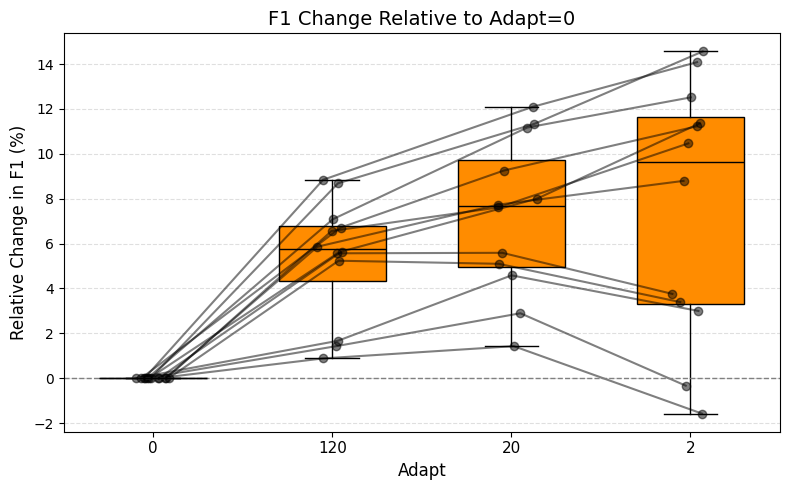

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'F1 Change Relative to Adapt=0'}, xlabel='Adapt', ylabel='Relative Change in F1 (%)'>)

In [246]:
plot_f1_relative_change_by_adapt(all_results_df, metric="F1", percent=True)

In [419]:
from matplotlib.patches import Patch
import numpy as np
import matplotlib.pyplot as plt

def plot_metrics_relative_change(df, metrics, percent=False, group_level="network"):
    df = df[df["Dataset"] != "Overall"].copy()

    colors = {
        "Precision": "royalblue",
        "Recall": "seagreen",
        "F1": "darkorange"
    }
    adapt_values = [0, 120, 20, 2]
    adapt_labels = ["Fixed", "60", "10", "1"]

    fig, ax = plt.subplots(figsize=(10, 6))
    width = 0.6
    positions = list(range(len(adapt_values)))

    if group_level.lower() == "channel":
        group_keys = ["Network", "Dataset", "Channel", "Adapt"]
    elif group_level.lower() == "dataset":
        group_keys = ["Network", "Dataset", "Adapt"]
    elif group_level.lower() == "network":
        group_keys = ["Network", "Adapt"]
    else:
        raise ValueError("group_level must be 'channel', 'dataset', or 'network'.")

    median_changes = {}

    for metric in metrics:
        mean_metric = df.groupby(group_keys)[metric].mean().reset_index()

        pivot_index = group_keys[:-1]
        pivot = mean_metric.pivot(index=pivot_index, columns="Adapt", values=metric)
        pivot = pivot[adapt_values]

        baseline = pivot[0]
        if percent:
            rel_change = (pivot.subtract(baseline, axis=0).divide(baseline, axis=0)) * 100
            ylabel = "Relative Change in Metric (%)"
        else:
            rel_change = pivot.subtract(baseline, axis=0)
            ylabel = "Change in Metric"

        # Store medians
        medians = rel_change.median(axis=0)
        median_changes[metric] = medians
        print(f"\nMedian changes for {metric}:")
        print(medians)

        data = [rel_change[a].values for a in adapt_values]

        for i, a in enumerate(adapt_values):
            bplot = ax.boxplot(
                data[i],
                positions=[positions[i]],
                widths=width,
                patch_artist=True,
                showfliers=False,
                medianprops=dict(color='black')
            )
            for patch in bplot['boxes']:
                patch.set_facecolor(colors.get(metric, "gray"))

        if metric == "F1":
            for row in rel_change.values:
                jitter = np.random.normal(0, 0.05, size=len(row))
                ax.plot(
                    np.array(positions) + jitter,
                    row,
                    marker='o',
                    color="black",
                    alpha=0.3,
                    linewidth=0.7
                )

    ax.set_xticks(positions)
    ax.set_xticklabels(adapt_labels, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(f"Change in Metrics Relative to Fixed ({group_level.capitalize()} level)", fontsize=16)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim(-1, len(adapt_values))
    ax.tick_params(axis='both', which='major', labelsize=14)

    plt.tight_layout()
    plt.show()

    return fig, ax, median_changes



Median changes for Precision:
Adapt
0       0.000000
120    11.114688
20     15.779323
2      23.281541
dtype: float64

Median changes for Recall:
Adapt
0       0.000000
120    -5.068684
20     -5.822057
2     -10.331704
dtype: float64

Median changes for F1:
Adapt
0      0.000000
120    5.755557
20     7.671345
2      9.631533
dtype: float64


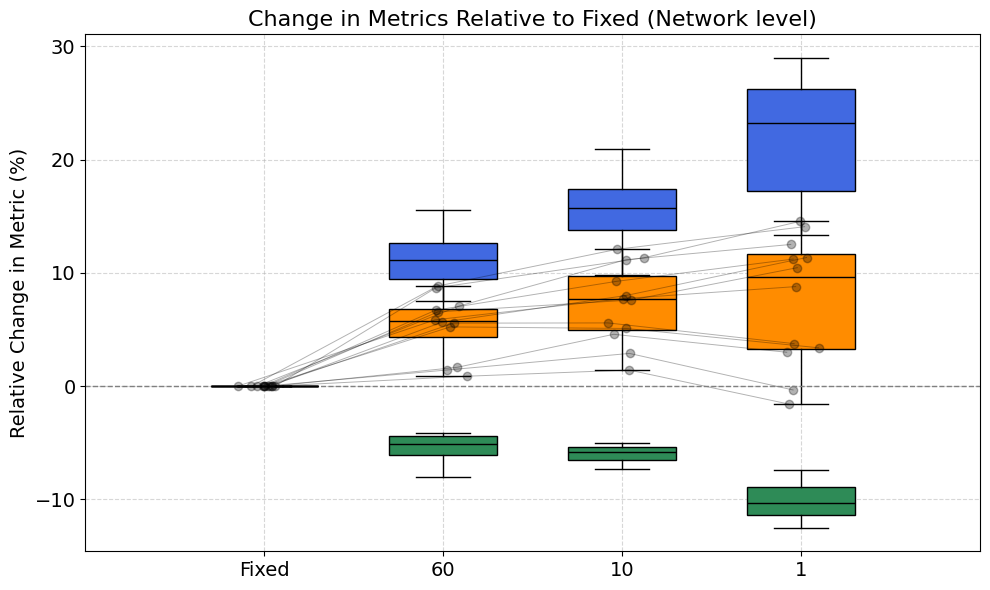

In [430]:
group_level = "Network"  # Change to "Dataset" or "Channel" as needed
fig,ax,median_change=plot_metrics_relative_change(df=all_results_df, metrics=["Precision", "Recall", "F1"], percent=True,group_level=group_level)
save_path = os.path.join("figures", f"metrics_relative_change_{group_level}.png")
fig.savefig(save_path, dpi=300, bbox_inches='tight')

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import wilcoxon
import itertools

def plot_violin_aggregated_with_points(df, metric="F1", group_level="Dataset"):
    adapt_values = [0, 120, 20, 2]
    colors = plt.cm.viridis_r(np.linspace(0.2, 0.8, len(adapt_values)))

    # Determine grouping columns based on group_level
    if group_level == "Channel":
        group_cols = ["Network", "Dataset", "Channel", "Adapt"]
    elif group_level == "Dataset":
        group_cols = ["Network", "Dataset", "Adapt"]
    elif group_level == "Network":
        group_cols = ["Network", "Adapt"]
    else:
        raise ValueError("group_level must be 'Channel', 'Dataset', or 'Network'.")

    # Average metric per group level & Adapt
    mean_metric = df.groupby(group_cols)[metric].mean().reset_index()

    violin_data = []
    for adapt in adapt_values:
        vals = mean_metric.loc[mean_metric["Adapt"] == adapt, metric].values
        violin_data.append(vals)

    positions = range(1, len(adapt_values) + 1)
    fig, ax = plt.subplots(figsize=(12, 7))

    # Violin plot
    parts = ax.violinplot(violin_data, positions=positions, showmeans=False, showmedians=True, showextrema=False)
    for i,vals in enumerate(violin_data):
        median = np.median(vals)
        ax.axhline(median, color=colors[i], linestyle='--', linewidth=1, alpha=0.5)

    # Color violins
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_edgecolor('black')
        pc.set_alpha(0.7)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)

   
    # Scatter jittered points~
    if group_level != "Channel":
        for pos, vals in zip(positions, violin_data):
            jitter = np.random.normal(0, 0.03, size=len(vals))
            ax.scatter(np.full(len(vals), pos) + jitter, vals, color='black', alpha=0.5, edgecolor='white', s=40, zorder=10)

    # Wilcoxon paired tests & annotate significance
    pairs = list(itertools.combinations(range(len(adapt_values)), 2))
    raw_pvals = []

    merged_datasets = []
    for (i, j) in pairs:
        set_i = mean_metric[mean_metric["Adapt"] == adapt_values[i]][group_cols[:-1] + [metric]]
        set_j = mean_metric[mean_metric["Adapt"] == adapt_values[j]][group_cols[:-1] + [metric]]
        merged = pd.merge(set_i, set_j, on=group_cols[:-1], suffixes=('_i', '_j'))
        merged_datasets.append(merged)
        if len(merged) > 0:
            _, p = wilcoxon(merged[f"{metric}_i"], merged[f"{metric}_j"])
        else:
            p = 1.0
        raw_pvals.append(p)

    adj_pvals, _ = holm_bonferroni(raw_pvals)

    # Annotate brackets
    height_increment = 0.02
    annotation_levels = np.zeros(len(adapt_values))
    for idx, ((i, j), p) in enumerate(zip(pairs, adj_pvals)):
        merged = merged_datasets[idx]
        if len(merged) == 0:
            continue
        level = int(max(annotation_levels[i], annotation_levels[j]))
        y = max(np.max(violin_data[i]), np.max(violin_data[j])) + level * height_increment
        if i==0 and j==3:
            y+=0.02
        barplot_annotate_brackets(i, j, p, positions, [y]*len(positions), ax,dh=0.04,barh=0)
        if p < 0.05:
        
            annotation_levels[i] = annotation_levels[j] = level + 1
        print(f"Wilcoxon Holm-Bonferroni between {adapt_values[i]} and {adapt_values[j]}: raw p={raw_pvals[idx]:.4e}, adj p={p:.4e}")

    # Formatting
    labels=["Fixed", "60", "10", "1"]
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, fontsize=14)
    ax.set_xlabel("Adapt", fontsize=14)
    ax.set_ylabel(f"Mean {metric} Score per {group_level}", fontsize=14)
    ax.set_title(f"{metric} Distribution Across Adapt Conditions ({group_level})", fontsize=16)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.tick_params(axis="both", which='major', labelsize=14)
    ax.set_ylim(0.35, 1.0)
    # ax.set_ylim(0.1,0.9)

    plt.tight_layout()
    plt.show()
    return fig, ax


Wilcoxon Holm-Bonferroni between 0 and 120: raw p=1.0875e-06, adj p=5.4376e-06
Wilcoxon Holm-Bonferroni between 0 and 20: raw p=8.2621e-07, adj p=4.9573e-06
Wilcoxon Holm-Bonferroni between 0 and 2: raw p=4.8964e-05, adj p=1.9586e-04
Wilcoxon Holm-Bonferroni between 120 and 20: raw p=7.9041e-03, adj p=2.3712e-02
Wilcoxon Holm-Bonferroni between 120 and 2: raw p=6.8399e-02, adj p=1.3680e-01
Wilcoxon Holm-Bonferroni between 20 and 2: raw p=3.7558e-01, adj p=3.7558e-01


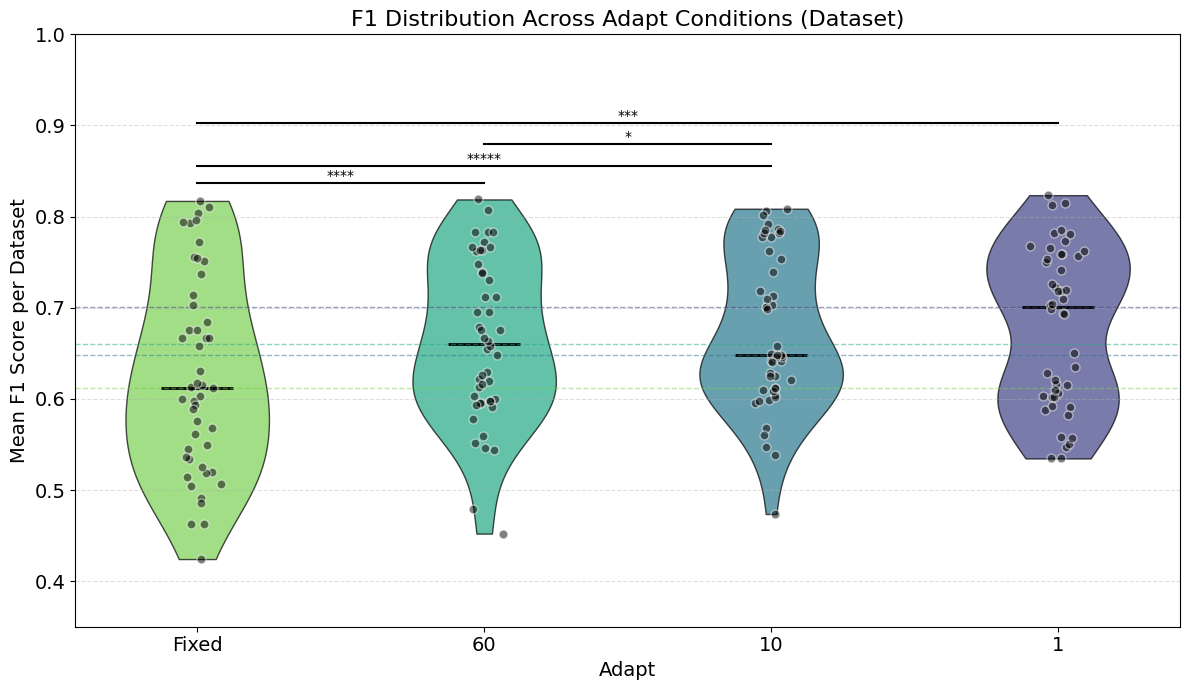

In [67]:
group_level="Dataset"
fig,ax=plot_violin_aggregated_with_points(all_results_df,metric="F1",group_level=group_level)
fig.savefig(f"figures\\violin_aggregated_with_points_{group_level}_3.png", dpi=300, bbox_inches='tight')